In [1]:
#Importing Libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D, Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

2026-02-27 17:34:11.857399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772213652.085315      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772213652.145638      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772213652.682463      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772213652.682504      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772213652.682507      55 computation_placer.cc:177] computation placer alr

In [2]:
base_dir = '/kaggle/input/datasets/kritikseth/fruit-and-vegetable-image-recognition'

In [3]:
train_path = os.path.join(base_dir, 'train')
test_path = os.path.join(base_dir, 'test')
validation_path = os.path.join(base_dir, 'validation')

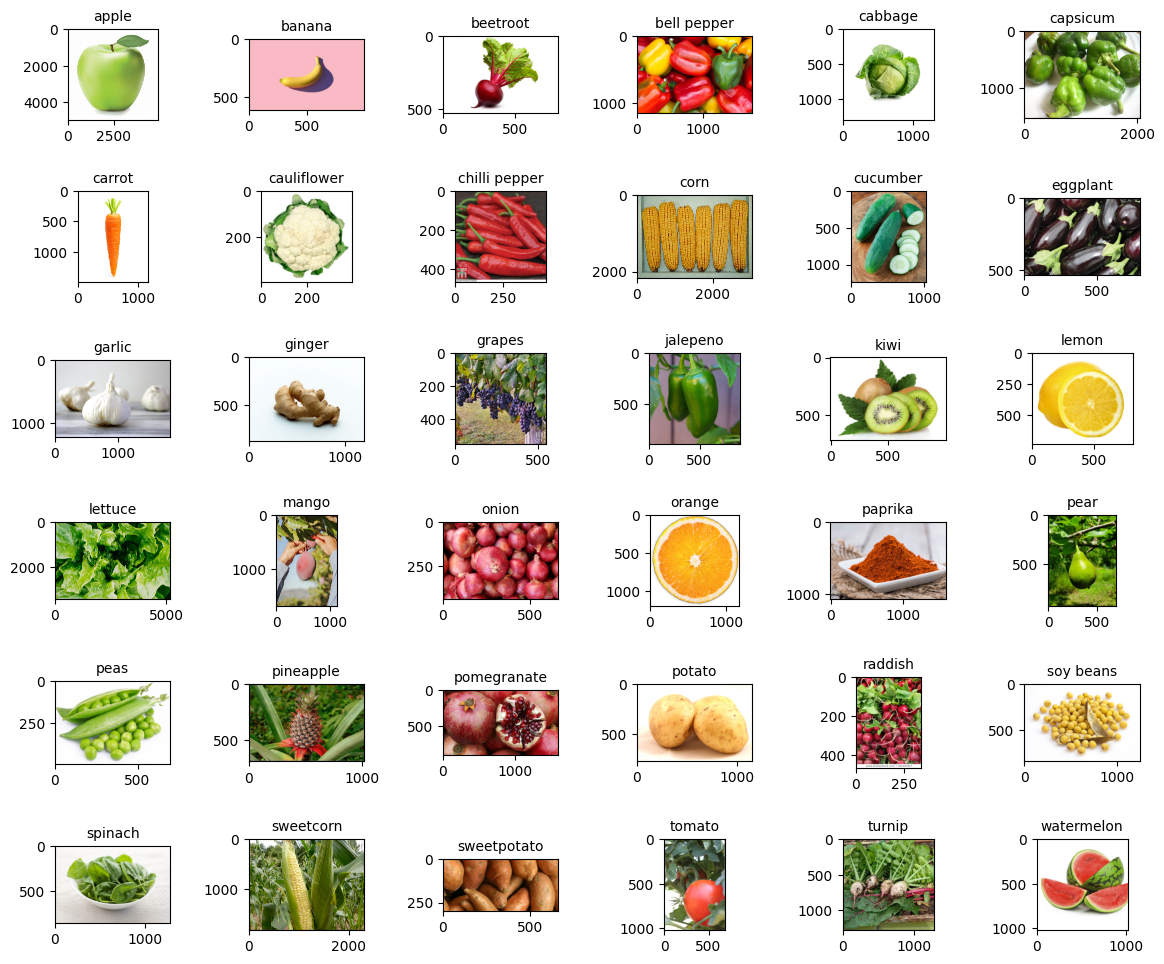

In [4]:
#Dataset Images Visulization 
categories = sorted(os.listdir(train_path))

# Initialize list for sample images
sample_images = []
for category in categories:
    category_path = os.path.join(train_path, category)  # Path to the category folder
    first_image = os.listdir(category_path)[0]  # Get the first image in the folder
    sample_images.append(os.path.join(category_path, first_image))  # Full path to the image

# (6x6) grid to plot the images
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(12, 10))

for ax, img_path, label in zip(axes.flat, sample_images, categories):
    ax.imshow(plt.imread(img_path))  # Display the image
    ax.set_title(label, fontsize=10)  # title for each image

# Adjust layout
plt.tight_layout(pad=2)
plt.show()

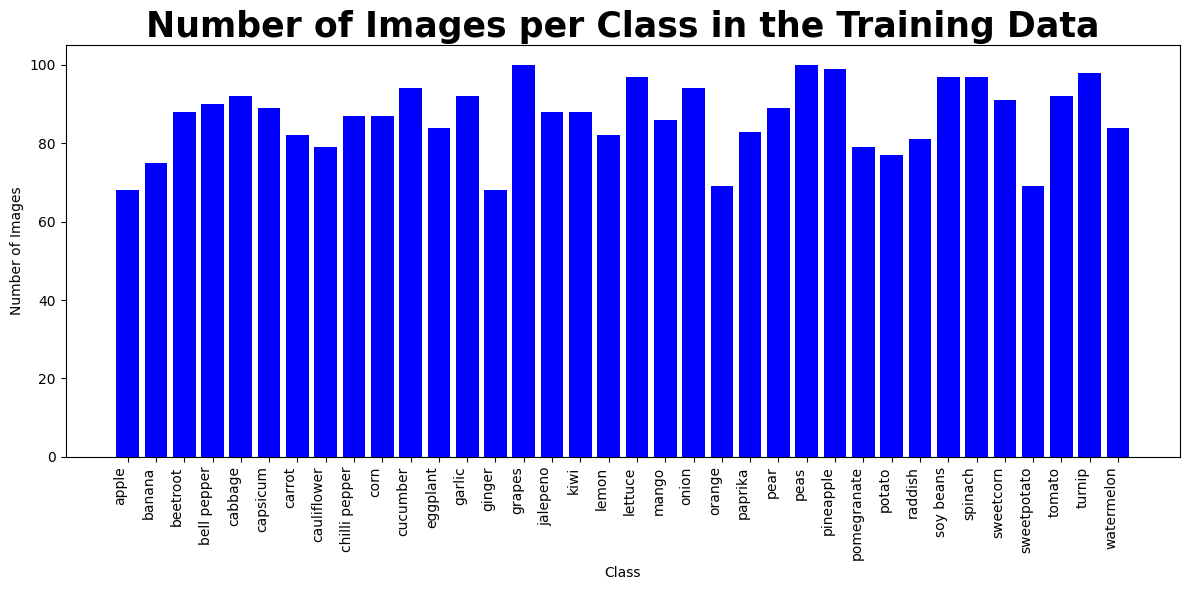

In [5]:
#Number of Images per Classes
# Get the list of all subdirectories (categories/classes)
classes = sorted(os.listdir(train_path))  # Sorting for consistency in display

# Count the number of images in each class
image_count = {}
for cls in classes:
    class_path = os.path.join(train_path, cls)
    image_count[cls] = len(os.listdir(class_path))

# Create a bar plot for image counts
plt.figure(figsize=(12, 6))
plt.bar(image_count.keys(), image_count.values(), color='blue')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Number of Images per Class in the Training Data' , fontsize=25, fontweight='bold')
plt.xticks(rotation=90, ha='right')  # Rotate class names for better readability
plt.tight_layout()  # Ensure everything fits
plt.show()

In [6]:
#Loading Data In batches
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(train_path,
                                                               image_size=(224, 224),
                                                              batch_size=32,
                                                                    seed=42)
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(validation_path,
                                                              image_size=(224, 224),
                                                              batch_size=32,
                                                                 seed = 42)

Found 3115 files belonging to 36 classes.


I0000 00:00:1772213686.366432      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772213686.372327      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 351 files belonging to 36 classes.


In [7]:
#Model Architecture CNN
# Define the model
model = Sequential()


# Convolutional Block 1
model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(224, 224, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Block 2
model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Block 3
model.add(Conv2D(128, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Block 4
model.add(Conv2D(96, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Block 5
model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten Layer
model.add(Flatten())

# Dense Layers
model.add(Dense(256, activation='relu'))  
model.add(Dropout(0.3))  

# Output Layer
model.add(Dense(36, activation='softmax'))

# Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 96)     │       110,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │        27,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       401,664 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 643,940 (2.46 MB)

 Trainable params: 643,236 (2.45 MB)

 Non-trainable params: 704 (2.75 KB)

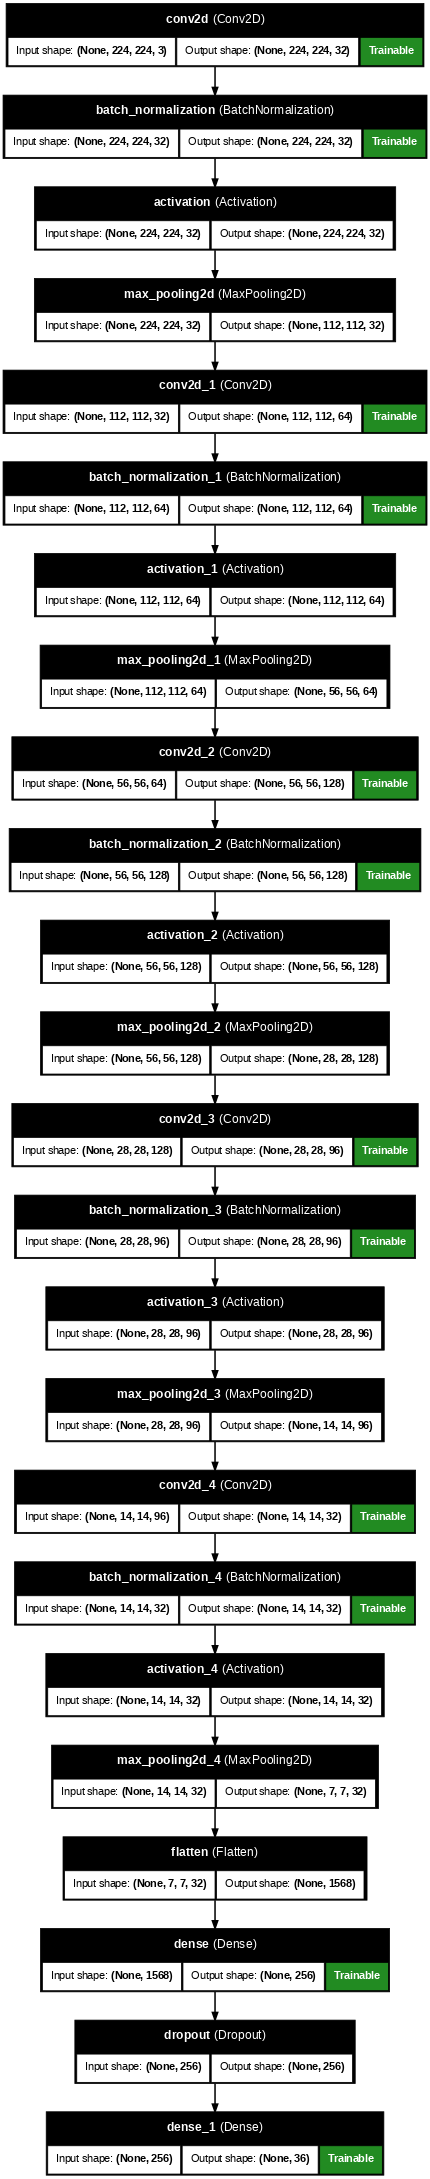

In [8]:
plot_model(
    model,
    to_file='model.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    dpi=55,
    show_layer_activations=False,
    show_trainable=True
)

In [9]:
#Training the model with EarlyStopping 
# EarlyStopping callback
callbacks = [
    EarlyStopping(
        monitor="val_loss",        # Monitor validation loss
        patience=5,               # Stop after 5 epochs without improvement
        restore_best_weights=True # Restore the best model weights
    )
]

# Train the model
history = model.fit(
    train_dataset,                # Training data (already batched)
    epochs=30,                    # Number of epochs
    validation_data=val_dataset,  # Validation data (already batched)
    callbacks=callbacks,          # Add EarlyStopping callback
    verbose=1                     # Show progress bars
)

Epoch 1/30


I0000 00:00:1772213692.853847     132 service.cc:152] XLA service 0x7af81c007210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772213692.853890     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772213692.853896     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772213693.884014     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/98 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.0391 - loss: 4.8632  

I0000 00:00:1772213701.712698     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


98/98 ━━━━━━━━━━━━━━━━━━━━ 52s 410ms/step - accuracy: 0.0851 - loss: 3.6742 - val_accuracy: 0.1168 - val_loss: 3.4562
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 26s 267ms/step - accuracy: 0.2112 - loss: 2.7471 - val_accuracy: 0.3533 - val_loss: 2.1242
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 26s 267ms/step - accuracy: 0.2971 - loss: 2.4191 - val_accuracy: 0.5812 - val_loss: 1.4526
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 269ms/step - accuracy: 0.3445 - loss: 2.1972 - val_accuracy: 0.4473 - val_loss: 1.8452
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 268ms/step - accuracy: 0.3915 - loss: 2.0025 - val_accuracy: 0.4701 - val_loss: 1.7947
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 26s 262ms/step - accuracy: 0.4379 - loss: 1.8385 - val_accuracy: 0.6182 - val_loss: 1.2543
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 271ms/step - accuracy: 0.4677 - loss: 1.7611 - val_accuracy: 0.5869 - val_loss: 1.3112
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 26s 267ms/step - accuracy: 0.4984 - loss: 1.6024 - val_accuracy: 0.643

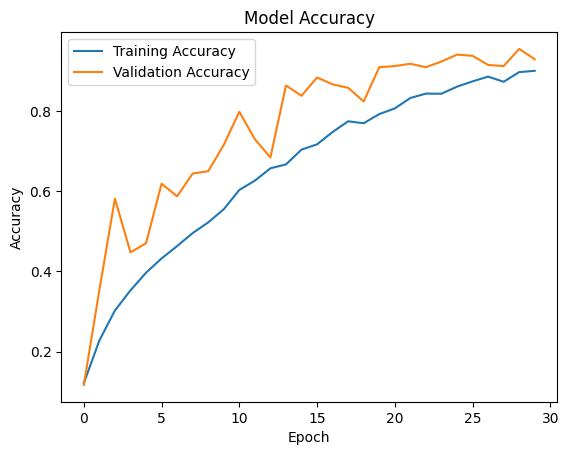

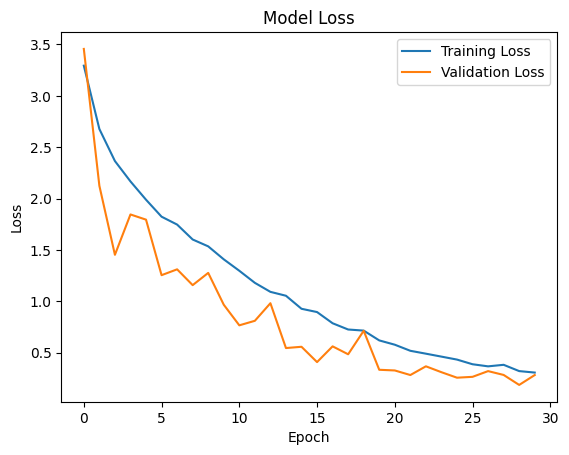

In [10]:
#Plotting Accuracy
# Plot training & validation accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot training & validation loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [11]:
# Load the test dataset
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,  # Path to the test dataset
    image_size=(224, 224),
    batch_size=32,
    seed=42
)

Found 359 files belonging to 36 classes.


In [12]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_dataset)

# Print the test accuracy and loss
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 448ms/step - accuracy: 0.9558 - loss: 0.1694
Test Loss: 0.18251915276050568
Test Accuracy: 0.9554317593574524


In [14]:
#Saving The model
model.save('model.h5')